<a href="https://colab.research.google.com/github/kapiljj/ML-projects/blob/main/qr_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install opencv-python scikit-image seaborn


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to dataset
first_print_path = '/content/drive/MyDrive/mlass/First Print'
second_print_path = '/content/drive/MyDrive/mlass/Second Print'

# Load images
first_print_images = [cv2.imread(os.path.join(first_print_path, f)) for f in os.listdir(first_print_path)]
second_print_images = [cv2.imread(os.path.join(second_print_path, f)) for f in os.listdir(second_print_path)]

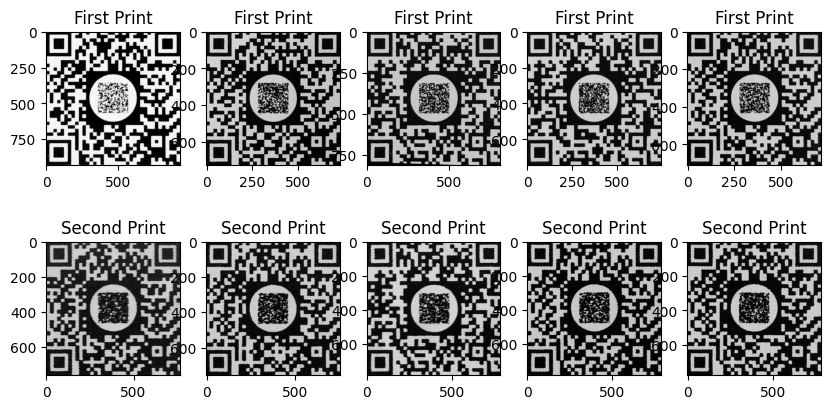

In [4]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(cv2.cvtColor(first_print_images[i], cv2.COLOR_BGR2RGB))
    plt.title('First Print')
    plt.subplot(2, 5, i+6)
    plt.imshow(cv2.cvtColor(second_print_images[i], cv2.COLOR_BGR2RGB))
    plt.title('Second Print')
plt.show()

In [16]:
from skimage.feature import local_binary_pattern

def extract_global_features(image):
    mean = np.mean(image)
    variance = np.var(image)
    return [mean, variance]

def extract_lbp_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp, bins=np.arange(0, 10), range=(0, 9))
    return hist

# Preprocess data
first_features = [extract_global_features(img) + list(extract_lbp_features(img)) for img in first_print_images]
second_features = [extract_global_features(img) + list(extract_lbp_features(img)) for img in second_print_images]

X = np.array(first_features + second_features)
y = np.array([0] * len(first_print_images) + [1] * len(second_print_images))

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.925
Confusion Matrix:
 [[20  1]
 [ 2 17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        21
           1       0.94      0.89      0.92        19

    accuracy                           0.93        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.93      0.93      0.92        40



In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/mlass',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)
val_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/mlass',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=val_generator, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4429 - loss: 1.3838 - val_accuracy: 0.5000 - val_loss: 0.6795
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6411 - loss: 0.6460 - val_accuracy: 0.8250 - val_loss: 0.5738
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6799 - loss: 0.6097 - val_accuracy: 0.8500 - val_loss: 0.4871
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8832 - loss: 0.4564 - val_accuracy: 0.8500 - val_loss: 0.3747
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8778 - loss: 0.3469 - val_accuracy: 0.9000 - val_loss: 0.2957
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9314 - loss: 0.2482 - val_accuracy: 0.9000 - val_loss: 0.2671
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9381 - loss: 0.1896 - val_accuracy: 0.9500 - val_loss: 0.1815
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9744 - loss: 0.1346 - val_accuracy: 0.9750 - val_loss: 0.1475
Epoch 9/10
5/

In [10]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.9667 - loss: 0.0971
Validation Accuracy: 0.949999988079071


In [11]:
first_print_path = '/content/drive/MyDrive/mlass/First Print'
second_print_path = '/content/drive/MyDrive/mlass/Second Print'

In [12]:
test_image_path = '/content/drive/MyDrive/mlass/First Print/1.png'

In [13]:
test_image_path = '/content/drive/MyDrive/mlass/First Print/input_image_active.png'

In [17]:

from google.colab import drive
drive.mount('/content/drive')


import os
import cv2
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import local_binary_pattern


def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            images.append(img)
    return images


first_print_path = '/content/drive/MyDrive/mlass/First Print'
second_print_path = '/content/drive/MyDrive/mlass/Second Print'

first_print_images = load_images_from_folder(first_print_path)
second_print_images = load_images_from_folder(second_print_path)

print(f"Loaded {len(first_print_images)} real QR codes and {len(second_print_images)} fake QR codes.")


def extract_global_features(image):
    mean = np.mean(image)
    variance = np.var(image)
    return [mean, variance]

def extract_lbp_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp, bins=np.arange(0, 10), range=(0, 9))
    return hist

first_features = [extract_global_features(img) + list(extract_lbp_features(img)) for img in first_print_images]
second_features = [extract_global_features(img) + list(extract_lbp_features(img)) for img in second_print_images]


X = np.array(first_features + second_features)
y = np.array([0] * len(first_print_images) + [1] * len(second_print_images))


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

def predict_qr_code(image_path):

    img = cv2.imread(image_path)
    if img is None:
        return "Invalid image path."


    features = extract_global_features(img) + list(extract_lbp_features(img))
    features = np.array(features).reshape(1, -1)


    prediction = model.predict(features)
    return "Real QR Code" if prediction == 0 else "Fake QR Code"

test_image_path = '/content/drive/MyDrive/mlass/First Print/input_image_active.png'
result = predict_qr_code(test_image_path)
print(f"Prediction for {test_image_path}: {result}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 100 real QR codes and 100 fake QR codes.
Accuracy: 0.925
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        21
           1       0.94      0.89      0.92        19

    accuracy                           0.93        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.93      0.93      0.92        40

Prediction for /content/drive/MyDrive/mlass/First Print/input_image_active.png: Real QR Code
